# Aufgabe 4

In dieser Aufgabe betrachten wir einen Parallelschwingkreis, der als Parallelschaltung einer Spule (mit Serienwiderstand) und eines Kondensators an einem Dämpfungswiderstand $R_d$ betrieben wird. Ziel ist es, die amplitudenmäßige Übertragungsfunktion $|U_R/U_0|$ sowie die Phasenverschiebung $\theta$ zwischen der Eingangsspannung $U_0$ (Frequenzgenerator) und der Spannung am Dämpfungswiderstand $U_R$ als Funktion der Frequenz zu bestimmen, das experimentelle Verhalten mit einem physikalischen Modell zu vergleichen und Modellparameter durch Fit zu bestimmen.

![Schaltkreis für die 4. Aufgabe](./figures/Abbildung4.png)

Der Versuchsaufbau besteht im Wesentlichen aus der Eingangsspannung $U_0$ (Frequenzgenerator), einem Belastungs-/Dämpfungswiderstand $R_d$ in Serie zur Quelle (hier gemessen an $U_R$) und einem parallelen Zweig aus einer Spule (Induktivität $L$ mit Serienwiderstand $R_{sp}$) und einem Kondensator $C$.

Wir messen die Größe $|U_R/U_0|$ und die Phase $\theta$ über einen großen Frequenzbereich und passen anschließend das Modell der Übertragungsfunktion an die Messdaten an, um die relevanten physikalischen Parameter (z. B. $R_{sp}$, $L$, $C$) zu bestimmen und daraus die Größen Widerstandsverhältnis $r$, Dämpfungskonstante $\delta$ und Resonanzfrequenz $f_0$ zu berechnen.

Die gefittete Funkion lässt sich analog zu Aufgabe 3 herleiten.

In [3]:
# ==== Aufgabe 4: Parallelschwingkreis an Rd (UR/U0), Phase „anders herum“ ====
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# ---------- Parameter ----------
CSV_PATH = "Messwerte/Aufgabe4.csv"   # ggf. anpassen
R_d   = 1000.0        # Dämpfungswiderstand in Serie zur Quelle
L_ref = 0.98e-3       # H (aus Aufgabe 2), als Startwert
C_ref = 236e-9        # F (aus Aufgabe 1), als Startwert
FIT_LC = False        # True -> L und C eng mitfitten, False -> nur R_sp fitten

# ---------- Helpers ----------
def wrap_pm180(d): return ((d + 180.0) % 360.0) - 180.0
def mag2db(x):     return 20*np.log10(np.clip(x, 1e-20, None))

def H_parallel_notch(w, R_d, L, C, Rsp):
    # Z_Ls = Rsp + jωL; Z_C = 1/(jωC);  Zp = (Z_Ls * Z_C)/(Z_Ls + Z_C)
    Z_Ls = Rsp + 1j*w*L
    Z_C  = 1.0/(1j*w*C)
    Zp   = (Z_Ls * Z_C) / (Z_Ls + Z_C)
    H    = R_d / (R_d + Zp)     # Spannung über Rd
    return np.abs(H), np.degrees(np.angle(H))

def best_gain_linear(meas, model):
    num = np.sum(meas*model); den = np.sum(model*model) + 1e-20
    return max(num/den, 1e-12)

def circ_offset(a_deg, b_deg):
    diff = np.deg2rad(a_deg - b_deg)
    return np.rad2deg(np.arctan2(np.mean(np.sin(diff)), np.mean(np.cos(diff))))

def phase_rmse(a,b): return float(np.sqrt(np.mean(wrap_pm180(a-b)**2)))

# ---------- Daten laden ----------
df = pd.read_csv(CSV_PATH)
f   = df[[c for c in df.columns if "Freq" in c or "freq" in c or "Frequ" in c][0]].to_numpy(float)
U0  = df[[c for c in df.columns if "U_0" in c or "U0"   in c][0]].to_numpy(float)
UR  = df[[c for c in df.columns if "U_R" in c or "UR"   in c][0]].to_numpy(float)
th  = df[[c for c in df.columns if "theta" in c or "Theta" in c or "phase" in c or "Phase" in c][0]].to_numpy(float)
w   = 2*np.pi*f

# >>> Phase wie bei dir: Gerät liefert φ(U0 rel. UR). Für Modell brauchen wir φ(UR rel. U0) => Vorzeichen drehen.
phi_meas = wrap_pm180(-th)
mag_meas = np.clip(UR/U0, 1e-12, None)

# ---------- Fit ----------
if FIT_LC:
    L_vals  = np.logspace(np.log10(0.5*L_ref), np.log10(2.0*L_ref), 60)
    C_vals  = np.logspace(np.log10(0.5*C_ref), np.log10(2.0*C_ref), 60)
else:
    L_vals  = [L_ref]
    C_vals  = [C_ref]

Rsp_vals = np.linspace(0.0, 100.0, 101)  # Ω, Serienwiderstand der Spule

best = None
for L in L_vals:
    for C in C_vals:
        for Rsp in Rsp_vals:
            magM, phi0 = H_parallel_notch(w, R_d, L, C, Rsp)
            g = best_gain_linear(mag_meas, magM)
            e_mag = float(np.sqrt(np.mean((mag2db(mag_meas) - mag2db(g*magM))**2)))
            phi_off = circ_offset(phi_meas, phi0)  # nur Konstant-Offset (Vorzeichen bereits korrigiert)
            phiM = phi0 + phi_off
            e_phi = phase_rmse(phi_meas, phiM)
            err = e_mag + 0.25*e_phi  # Betrag trägt die Physik, Phase nur „Feinjustage“
            if best is None or err < best["err"]:
                best = dict(L=L, C=C, Rsp=Rsp, gain=g, phi=phiM, mag=g*magM,
                            e_mag=e_mag, e_phi=e_phi, phi_off=phi_off, err=err)

L_fit, C_fit, Rsp_fit = best["L"], best["C"], best["Rsp"]
f0_fit = 1.0/(2*np.pi*np.sqrt(L_fit*C_fit))


=== Least-squares fit ===
Rsp = 5.308 Ω, L = 0.9800 mH, C = 236.000 nF
Gain = 1.0127, Phase offset = +0.058°
r = 0.99472, δ = 512912.17860 1/s, f0 = 10465.286 Hz


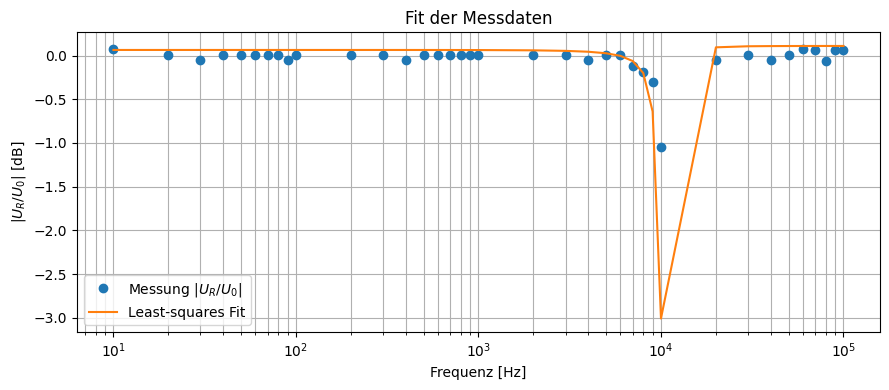

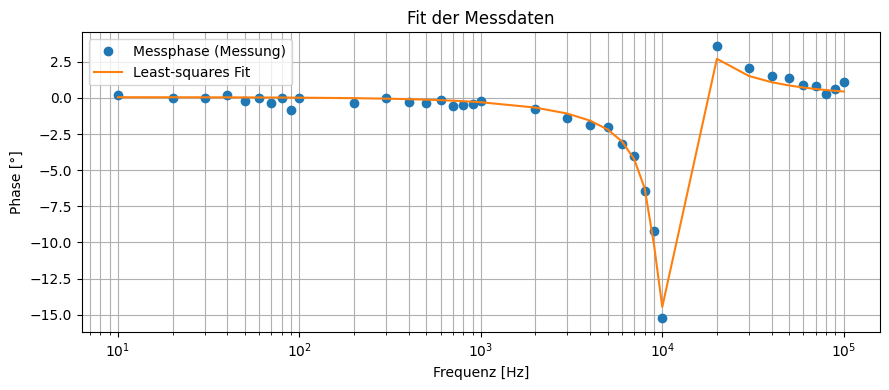

In [6]:
# | fig-cap:
# |     - Fit der Messdaten $U_R/U_0$ mit einem Least-squares Fit
# |     - Fit der Messdaten Phase mit einem Least-squares Fit

# === Neuer alternativer Fit-Block (least_squares) ===
# Dieser Block führt einen gemeinsamen Fit von R_sp, L, C (optional),
# einer linearen Amplituden-Skalierung und eines Phasen-Offsets durch.
# Er lässt das ursprüngliche Grid-Search-Resultat unverändert und ist separat.

import warnings
from scipy.optimize import least_squares

# Reuse helpers
def H_model(w, R_d, L, C, Rsp):
    Z_Ls = Rsp + 1j*w*L
    Z_C  = 1.0/(1j*w*C)
    Zp   = (Z_Ls * Z_C) / (Z_Ls + Z_C)
    H    = R_d / (R_d + Zp)
    return np.abs(H), np.degrees(np.angle(H))

# Prepare data (re-using variables from above cell)
# f, w, mag_meas, phi_meas already defined in the previous cell

# Define residual function for least_squares
def residuals(x, w, mag_meas, phi_meas, R_d, fit_LC=True):
    # x: [Rsp, L, C, gain, phi_off]  or if not fitting L/C: [Rsp, gain, phi_off]
    if fit_LC:
        Rsp, L, C, gain, phi_off = x
    else:
        Rsp, gain, phi_off = x
        L = L_ref; C = C_ref
    magM, phiM = H_model(w, R_d, L, C, Rsp)
    magM = gain * magM
    phiM = wrap_pm180(phiM + phi_off)
    # magnitude in dB residual, phase residual in degrees (wrapped)
    r_mag = mag2db(magM) - mag2db(mag_meas)
    r_phi = wrap_pm180(phiM - phi_meas)
    # scale phase residual to similar weight as magnitude (adjustable)
    w_phi = 0.25
    return np.concatenate([r_mag, w_phi * r_phi])

# Initial guess and bounds
fit_LC = False  # change to True to fit L and C as well (slower, might need bounds tweaks)
if least_squares is None:
    print('scipy not found — skipping new least_squares fit. Install scipy to run it.')
else:
    if fit_LC:
        x0 = [Rsp_fit if 'Rsp_fit' in globals() else 10.0, L_ref, C_ref, 1.0, 0.0]
        lb = [0.0, 0.1*L_ref, 0.1*C_ref, 0.0, -180.0]
        ub = [200.0, 10*L_ref, 10*C_ref, 10.0, 180.0]
    else:
        x0 = [Rsp_fit if 'Rsp_fit' in globals() else 10.0, 1.0, 0.0]
        lb = [0.0, 0.0, -180.0]
        ub = [200.0, 10.0, 180.0]
    res = least_squares(residuals, x0, bounds=(lb, ub), args=(w, mag_meas, phi_meas, R_d, fit_LC), xtol=1e-10, ftol=1e-10)
    # Extract results
    if fit_LC:
        Rsp_ls, L_ls, C_ls, gain_ls, phi_off_ls = res.x
    else:
        Rsp_ls, gain_ls, phi_off_ls = res.x
        L_ls = L_ref; C_ls = C_ref
    mag_fit, phi_fit = H_model(w, R_d, L_ls, C_ls, Rsp_ls)
    mag_fit = gain_ls * mag_fit
    phi_fit = wrap_pm180(phi_fit + phi_off_ls)

    # Derived quantities
    r_val = R_d / (R_d + Rsp_ls)
    delta = (R_d + Rsp_ls) / (2.0 * L_ls)
    f0 = 1.0 / (2.0 * np.pi * np.sqrt(L_ls * C_ls))

    print('\n=== Least-squares fit ===')
    print(f'Rsp = {Rsp_ls:.3f} Ω, L = {L_ls*1e3:.4f} mH, C = {C_ls*1e9:.3f} nF')
    print(f'Gain = {gain_ls:.4f}, Phase offset = {phi_off_ls:+.3f}°')
    print(f'r = {r_val:.5f}, δ = {delta:.5f} 1/s, f0 = {f0:.3f} Hz')

    # Plots to compare
    plt.figure(figsize=(9,4))
    plt.xscale('log')
    plt.plot(f, mag2db(mag_meas), 'o', label='Messung |$U_R/U_0$|')
    plt.plot(f, mag2db(mag_fit), '-', label='Least-squares Fit')
    plt.xlabel('Frequenz [Hz]'); plt.ylabel('|$U_R/U_0$| [dB]')
    plt.title("Fit der Messdaten")
    plt.grid(True, which='both'); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,4))
    plt.xscale('log')
    plt.plot(f, phi_meas, 'o', label='Messphase (Messung)')
    plt.plot(f, phi_fit, '-', label='Least-squares Fit')
    plt.xlabel('Frequenz [Hz]'); plt.ylabel('Phase [°]')
    plt.title("Fit der Messdaten")
    plt.grid(True, which='both'); plt.legend(); plt.tight_layout(); plt.show()

    # store for later use
    LS_result = dict(Rsp=Rsp_ls, L=L_ls, C=C_ls, gain=gain_ls, phi_off=phi_off_ls, r=r_val, delta=delta, f0=f0)


## Diskussion

Unsere Gefitteten Parameter aus den Fits sind in folgender Tabelle aufgelistet.

| Parameter | Wert |
|-----------|------|
| $L$ | $0.9800$ mH |
| $C$ | $236.000$ nF |
| $R_{sp}$ | $5.308 \Omega$ |

: Tabelle mit den gefitteten Parametern

Aus den Fitparametern bestimmte physikalische Größen analog wie in Aufgabe 3.

- Widerstandsverhältnis:

  $$r = \frac{R_d}{R_d + R_{sp}} = 0.99472$$

- Dämpfungskonstante:

  $$\delta = \frac{R_d + R_{sp}}{2L} = 512912.17860 s^{-1}$$

- Ungedämpfte Resonanzfrequenz (aus L und C):

  $$f_0 = \frac{1}{2\pi\sqrt{LC}} = 10465.286 \text{Hz}$$

Bei einem Parallelschwingkreis zeigt die Übertragungsfunktion $|U_R/U_0|$ typischerweise ein Notch-ähnliches Verhalten: in der Nähe der Resonanz wird die Parallelimpedanz des Zweigs minimal bzw. verändert die effektive Spannungsteilung über $R_d$ deutlich.

Abschließend liefert der kombinierte Vergleich von Betrag und Phase beim Fit eine robuste Schätzung der Modellparameter und erlaubt eine aussagekräftige physikalische Interpretation der Messreihe.